In [1]:
# load netcdf from OM4 runs

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import cartopy.crs as ccrs
from matplotlib.colorbar import ColorbarBase

/orcd/home/001/abodner/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/new_runs/'


# load FK MLD data 
ds_MLD_EN1_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN1.nc')
ds_MLD_EN2_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN2.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_FK = ds_MLD_EN1_FK.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(0,503))
MLD_winter_SH_FK = ds_MLD_EN2_FK.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(0,503))

# Northern Hemisphere (NH)
MLD_summer_NH_FK = ds_MLD_EN1_FK.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(503,1080))
MLD_winter_NH_FK = ds_MLD_EN2_FK.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(503,1080))

# concat SH and NH for summer and winter datasets
MLD_summer_FK = xr.concat([MLD_summer_SH_FK, MLD_summer_NH_FK], "yh")
MLD_winter_FK = xr.concat([MLD_winter_SH_FK, MLD_winter_NH_FK], "yh")


# load BD MLD data 
ds_MLD_EN1_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN1.nc')
ds_MLD_EN2_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN2.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_BD = ds_MLD_EN1_BD.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(0,503))
MLD_winter_SH_BD = ds_MLD_EN2_BD.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(0,503))

# Northern Hemisphere (NH)
MLD_summer_NH_BD = ds_MLD_EN1_BD.MLD_EN1.groupby("time.season").mean('time',skipna=True).sel(season='JJA').isel(yh=range(503,1080))
MLD_winter_NH_BD = ds_MLD_EN2_BD.MLD_EN2.groupby("time.season").mean('time',skipna=True).sel(season='DJF').isel(yh=range(503,1080))

# concat SH and NH for summer and winter datasets
MLD_summer_BD = xr.concat([MLD_summer_SH_BD, MLD_summer_NH_BD], "yh")
MLD_winter_BD = xr.concat([MLD_winter_SH_BD, MLD_winter_NH_BD], "yh")





# load static file
#ds_stat = xr.open_dataset(BASE+'ocean_annual_z.static.nc')

/tmp/ipykernel_44455/1331027429.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN1_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN1.nc')
/tmp/ipykernel_44455/1331027429.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN2_FK = xr.open_dataset(BASE+'BFF11/ocean_monthly.201801-202212.MLD_EN2.nc')
/tmp/ipykernel_44455/1331027429.py:24: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_MLD_EN1_BD = xr.open_dataset(BASE+'BOD23/ocean_monthly.201801-202212.MLD_EN1.nc')
/tmp/ipykernel_44455/133102742

In [3]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/'


# load ARGO MLD data 
ds_MLD_EN1_ARGO = xr.open_dataset(BASE+'Argo_MLD.mld_pe_anomaly_25.nc')
ds_MLD_EN2_ARGO = xr.open_dataset(BASE+'Argo_MLD.mld_pe_anomaly_2500.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_ARGO = ds_MLD_EN1_ARGO.MLD_mean.sel(Month=[12,1,2]).mean('Month',skipna=True).sel(Lat=slice(-90,0))
MLD_winter_SH_ARGO = ds_MLD_EN2_ARGO.MLD_mean.sel(Month=[6,7,8]).mean('Month',skipna=True).sel(Lat=slice(-90,0))

                                                                           
# Northern Hemisphere (NH)
MLD_summer_NH_ARGO = ds_MLD_EN1_ARGO.MLD_mean.sel(Month=[6,7,8]).mean('Month',skipna=True).sel(Lat=slice(0,90))
MLD_winter_NH_ARGO = ds_MLD_EN2_ARGO.MLD_mean.sel(Month=[12,1,2]).mean('Month',skipna=True).sel(Lat=slice(0,90))

# concat SH and NH for summer and winter datasets
MLD_summer_ARGO = xr.concat([MLD_summer_SH_ARGO, MLD_summer_NH_ARGO], "Lat")
MLD_winter_ARGO = xr.concat([MLD_winter_SH_ARGO, MLD_winter_NH_ARGO], "Lat")


# interpolate ARGO data to the same grid as OM4 (first need to shift lon to -300:60

MLD_summer_ARGO_interp = MLD_summer_ARGO.roll(Lon=150).assign_coords(Lon=(MLD_summer_ARGO.Lon - 300)).interp(Lon=MLD_winter_BD.xh, Lat = MLD_winter_BD.yh, method="linear")
MLD_winter_ARGO_interp = MLD_winter_ARGO.roll(Lon=150).assign_coords(Lon=(MLD_winter_ARGO.Lon - 300)).interp(Lon=MLD_winter_BD.xh, Lat = MLD_winter_BD.yh, method="linear")

In [4]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/'


# load ARGO MLD data 
ds_MLD_EN1_ARGO = xr.open_dataset(BASE+'Argo_MLD.mld_pe_anomaly_25.nc')
ds_MLD_EN2_ARGO = xr.open_dataset(BASE+'Argo_MLD.mld_pe_anomaly_2500.nc')

# group by season and take mean over summer (EN1) and winter (EN2) for last 5 years of JRA cycle
# Southern Hemisphere (SH)
MLD_summer_SH_ARGO = ds_MLD_EN1_ARGO.MLD_mean.sel(Month=[12,1,2]).mean('Month',skipna=True).sel(Lat=slice(-90,0))
MLD_winter_SH_ARGO = ds_MLD_EN2_ARGO.MLD_mean.sel(Month=[6,7,8]).mean('Month',skipna=True).sel(Lat=slice(-90,0))

                                                                           
# Northern Hemisphere (NH)
MLD_summer_NH_ARGO = ds_MLD_EN1_ARGO.MLD_mean.sel(Month=[6,7,8]).mean('Month',skipna=True).sel(Lat=slice(0,90))
MLD_winter_NH_ARGO = ds_MLD_EN2_ARGO.MLD_mean.sel(Month=[12,1,2]).mean('Month',skipna=True).sel(Lat=slice(0,90))

# concat SH and NH for summer and winter datasets
MLD_summer_ARGO = xr.concat([MLD_summer_SH_ARGO, MLD_summer_NH_ARGO], "Lat")
MLD_winter_ARGO = xr.concat([MLD_winter_SH_ARGO, MLD_winter_NH_ARGO], "Lat")


# interpolate ARGO data to the same grid as OM4 (first need to shift lon to -300:60

MLD_summer_ARGO_interp = MLD_summer_ARGO.roll(Lon=150).assign_coords(Lon=(MLD_summer_ARGO.Lon - 300)).interp(Lon=MLD_winter_BD.xh, Lat = MLD_winter_BD.yh, method="linear")
MLD_winter_ARGO_interp = MLD_winter_ARGO.roll(Lon=150).assign_coords(Lon=(MLD_winter_ARGO.Lon - 300)).interp(Lon=MLD_winter_BD.xh, Lat = MLD_winter_BD.yh, method="linear")

In [5]:
### BLOM ###
# path to dataset
PATH_BLOM = '/orcd/data/abodner/001/blom_output/'
# load BFF11 data 
BLOM_MLD_BFF11 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner01_MLD_5year_mean.nc')  

# load BOD23 data tuned
BLOM_MLD_BOD23 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner03_MLD_5year_mean.nc')  

#load grid
BLOM_grid = xr.open_dataset(PATH_BLOM+'grid_tnx1v4_20170622.nc')  


In [6]:
### CESM ###
# path to dataset
PATH_CESM = '/orcd/data/abodner/001/cesm_output/'
# load BFF11 data 
CESM_MLD_BFF11_summer = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_BLD_summer.nc')
CESM_MLD_BFF11_winter = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_BLD_winter.nc') 

# load BFF11 Li16 data 
#CESM_MLD_BFF11_Li16_summer = xr.open_dataset(PATH_CESM+'045_BFF11_Li16/ncfiles/g.e30_b05.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.045_MLD_summer.nc')
#CESM_MLD_BFF11_Li16_winter = xr.open_dataset(PATH_CESM+'045_BFF11_Li16/ncfiles/g.e30_b05.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.045_MLD_winter.nc')

# load BOD23 data tuned 
CESM_MLD_BOD23_summer = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_BLD_summer.nc')
CESM_MLD_BOD23_winter = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_BLD_winter.nc') 



In [7]:
# compute zonal mean
#argo
MLD_summer_ARGO_interp_zonal_mean = MLD_summer_ARGO_interp.mean('xh')
MLD_winter_ARGO_interp_zonal_mean = MLD_winter_ARGO_interp.mean('xh')

#gfdl
GFDL_MLD_BOD23_summer_zm = MLD_summer_BD.mean('xh')
GFDL_MLD_BOD23_winter_zm = MLD_winter_BD.mean('xh')

GFDL_MLD_BFF11_summer_zm = MLD_summer_FK.mean('xh')
GFDL_MLD_BFF11_winter_zm = MLD_winter_FK.mean('xh')

#cesm
CESM_MLD_BOD23_summer_zm = CESM_MLD_BOD23_summer.BLD_summer.mean('xh')
CESM_MLD_BOD23_winter_zm = CESM_MLD_BOD23_winter.BLD_winter.mean('xh')

CESM_MLD_BFF11_summer_zm = CESM_MLD_BFF11_summer.BLD_summer.mean('xh')
CESM_MLD_BFF11_winter_zm = CESM_MLD_BFF11_winter.BLD_winter.mean('xh')

#CESM_MLD_BFF11_Li16_summer_zm = CESM_MLD_BFF11_Li16_summer.MLD_summer.mean('xh')
#CESM_MLD_BFF11_Li16_winter_zm = CESM_MLD_BFF11_Li16_winter.MLD_winter.mean('xh')

#blom
BLOM_MLD_BFF11_summer_zm = BLOM_MLD_BFF11.mld_summer.mean('x')
BLOM_MLD_BFF11_winter_zm = BLOM_MLD_BFF11.mld_winter.mean('x')

BLOM_MLD_BOD23_summer_zm = BLOM_MLD_BOD23.mld_summer.mean('x')
BLOM_MLD_BOD23_winter_zm = BLOM_MLD_BOD23.mld_winter.mean('x')

BLOM_lat = BLOM_grid.qlat.mean('x')

## plot zonal MLD 

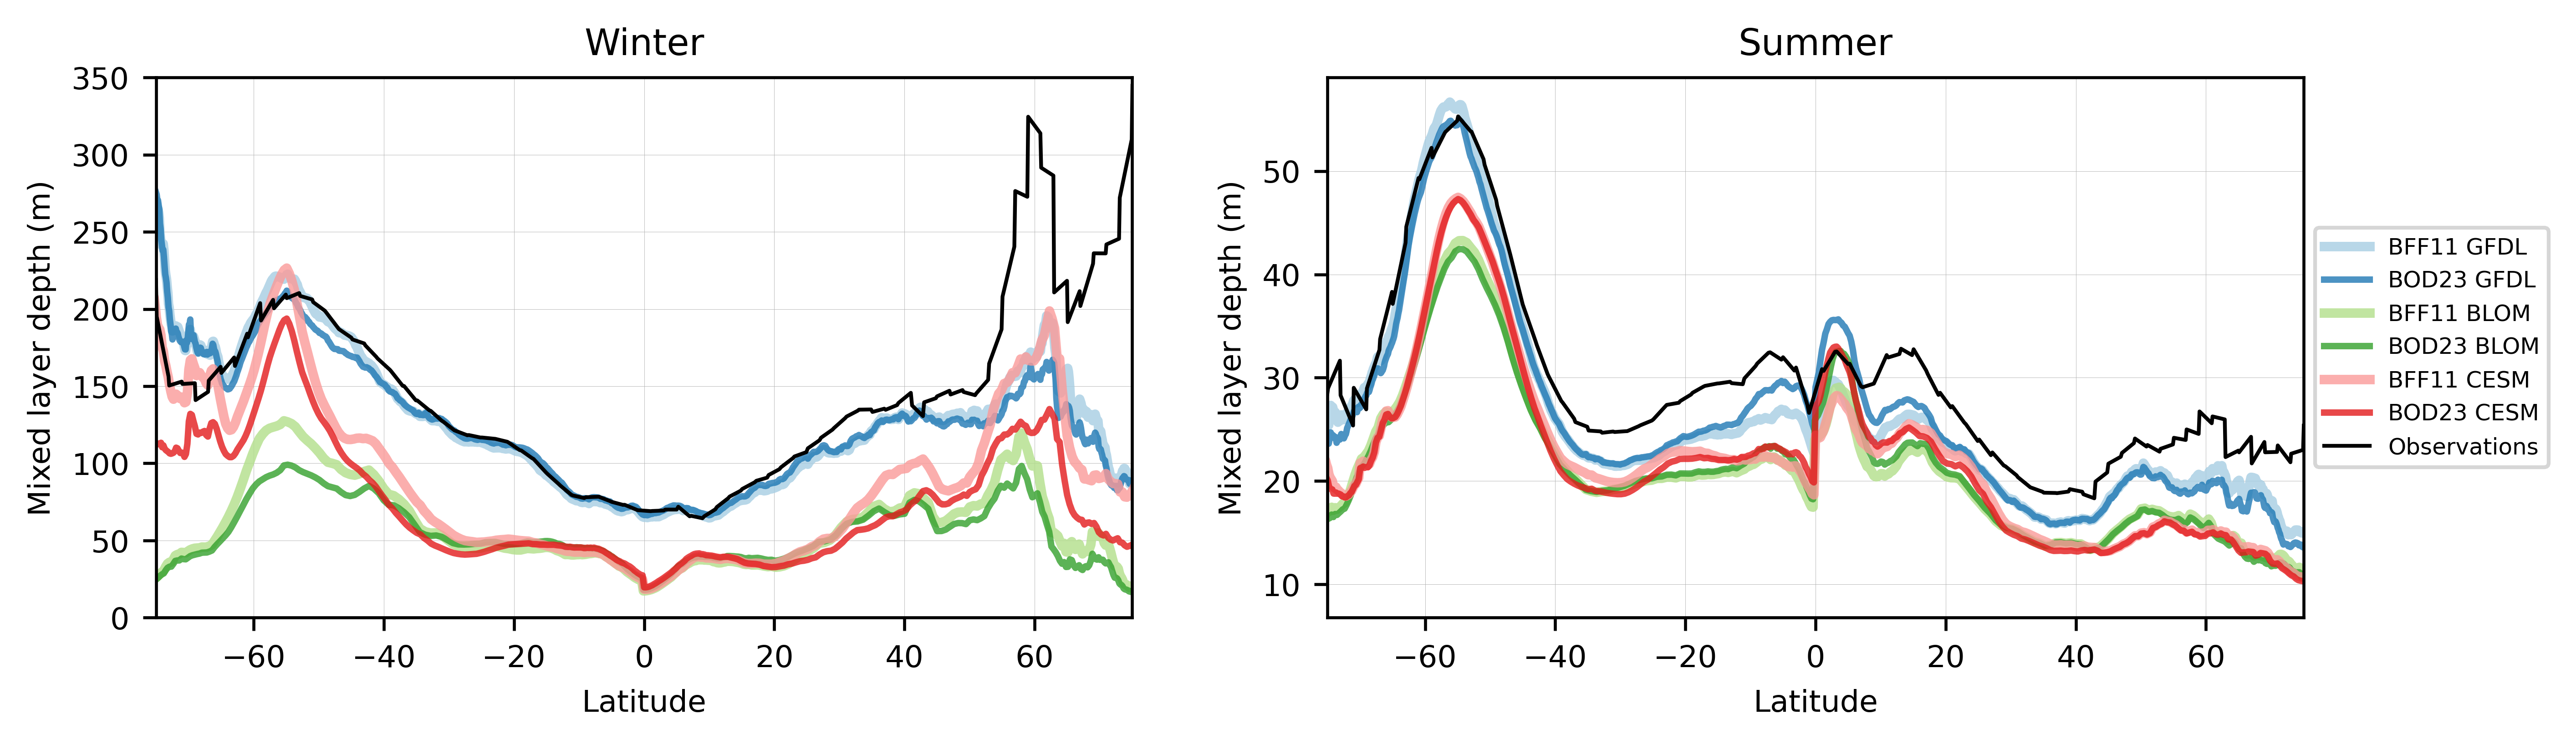

In [10]:
# create a figure
#fig = plt.figure()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), dpi=600)
fig.tight_layout(pad=8.0)


import matplotlib.pyplot as pl
colors = pl.cm.Paired(np.linspace(0,1,12))

plt.subplot(1,2,1)
plt.plot(GFDL_MLD_BFF11_winter_zm.yh.values,GFDL_MLD_BFF11_winter_zm.values,color=colors[0],label='BFF11 GFDL',linewidth =2.5,alpha=0.8)
plt.plot(GFDL_MLD_BOD23_winter_zm.yh.values,GFDL_MLD_BOD23_winter_zm.values,color=colors[1],label='BOD23 GFDL',linewidth =1.7,alpha=0.8)

plt.plot(BLOM_lat.values,BLOM_MLD_BFF11_winter_zm.values,color=colors[2],label='BFF11 BLOM',linewidth =2.5,alpha=0.8)
plt.plot(BLOM_lat.values,BLOM_MLD_BOD23_winter_zm.values,color=colors[3],label='BOD23 BLOM tuned',linewidth =1.7,alpha=0.8)

plt.plot(CESM_MLD_BFF11_winter_zm.yh.values,CESM_MLD_BFF11_winter_zm.values,color=colors[4],label='BFF11 CESM',linewidth =2.5,alpha=0.8)
plt.plot(CESM_MLD_BOD23_winter_zm.yh.values,CESM_MLD_BOD23_winter_zm.values,color=colors[5],label='BOD23 CESM',linewidth =1.7,alpha=0.8)
#plt.plot(CESM_MLD_BFF11_winter_zm.yh.values,CESM_MLD_BFF11_Li16_winter_zm.values,color=colors[6],label='BFF11 Li16 CESM',linewidth =1.7,alpha=0.8)

plt.plot(GFDL_MLD_BFF11_summer_zm.yh.values,MLD_winter_ARGO_interp_zonal_mean.values,color='k',label='BFF11 GFDL',linewidth =1)

plt.xlim([-75,75])
plt.ylim([0,350])
plt.grid(linewidth=.1)
#plt.legend(fontsize=6,loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Latitude')
plt.ylabel('Mixed layer depth (m)')
plt.title('Winter')


plt.subplot(1,2,2)
plt.plot(GFDL_MLD_BFF11_summer_zm.yh.values,GFDL_MLD_BFF11_summer_zm.values,color=colors[0],label='BFF11 GFDL',linewidth =2.5,alpha=0.8)
plt.plot(GFDL_MLD_BOD23_summer_zm.yh.values,GFDL_MLD_BOD23_summer_zm.values,color=colors[1],label='BOD23 GFDL',linewidth =1.7,alpha=0.8)

plt.plot(BLOM_lat.values,BLOM_MLD_BFF11_summer_zm.values,color=colors[2],label='BFF11 BLOM',linewidth =2.5,alpha=0.8)
plt.plot(BLOM_lat.values,BLOM_MLD_BOD23_summer_zm.values,color=colors[3],label='BOD23 BLOM',linewidth =1.7,alpha=0.8)

plt.plot(CESM_MLD_BFF11_summer_zm.yh.values,CESM_MLD_BFF11_summer_zm.values,color=colors[4],label='BFF11 CESM',linewidth =2.5,alpha=0.8)
plt.plot(CESM_MLD_BOD23_summer_zm.yh.values,CESM_MLD_BOD23_summer_zm.values,color=colors[5],label='BOD23 CESM',linewidth =1.7,alpha=0.8)
#plt.plot(CESM_MLD_BFF11_summer_zm.yh.values,CESM_MLD_BFF11_Li16_summer_zm.values,color=colors[6],label='BFF11 Li16 CESM',linewidth =1.7,alpha=0.8)



plt.plot(GFDL_MLD_BFF11_summer_zm.yh.values,MLD_summer_ARGO_interp_zonal_mean.values,color='k',label='Observations',linewidth =1)


plt.xlim([-75,75])
plt.grid(linewidth=.1)
plt.legend(fontsize=6,loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Latitude')
plt.ylabel('Mixed layer depth (m)')
plt.title('Summer')

plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(wspace=0.2)

# save figure
plt.savefig('./figures/MLD_zonal_mean')



ValueError: operands could not be broadcast together with shapes (385,) (1080,) 

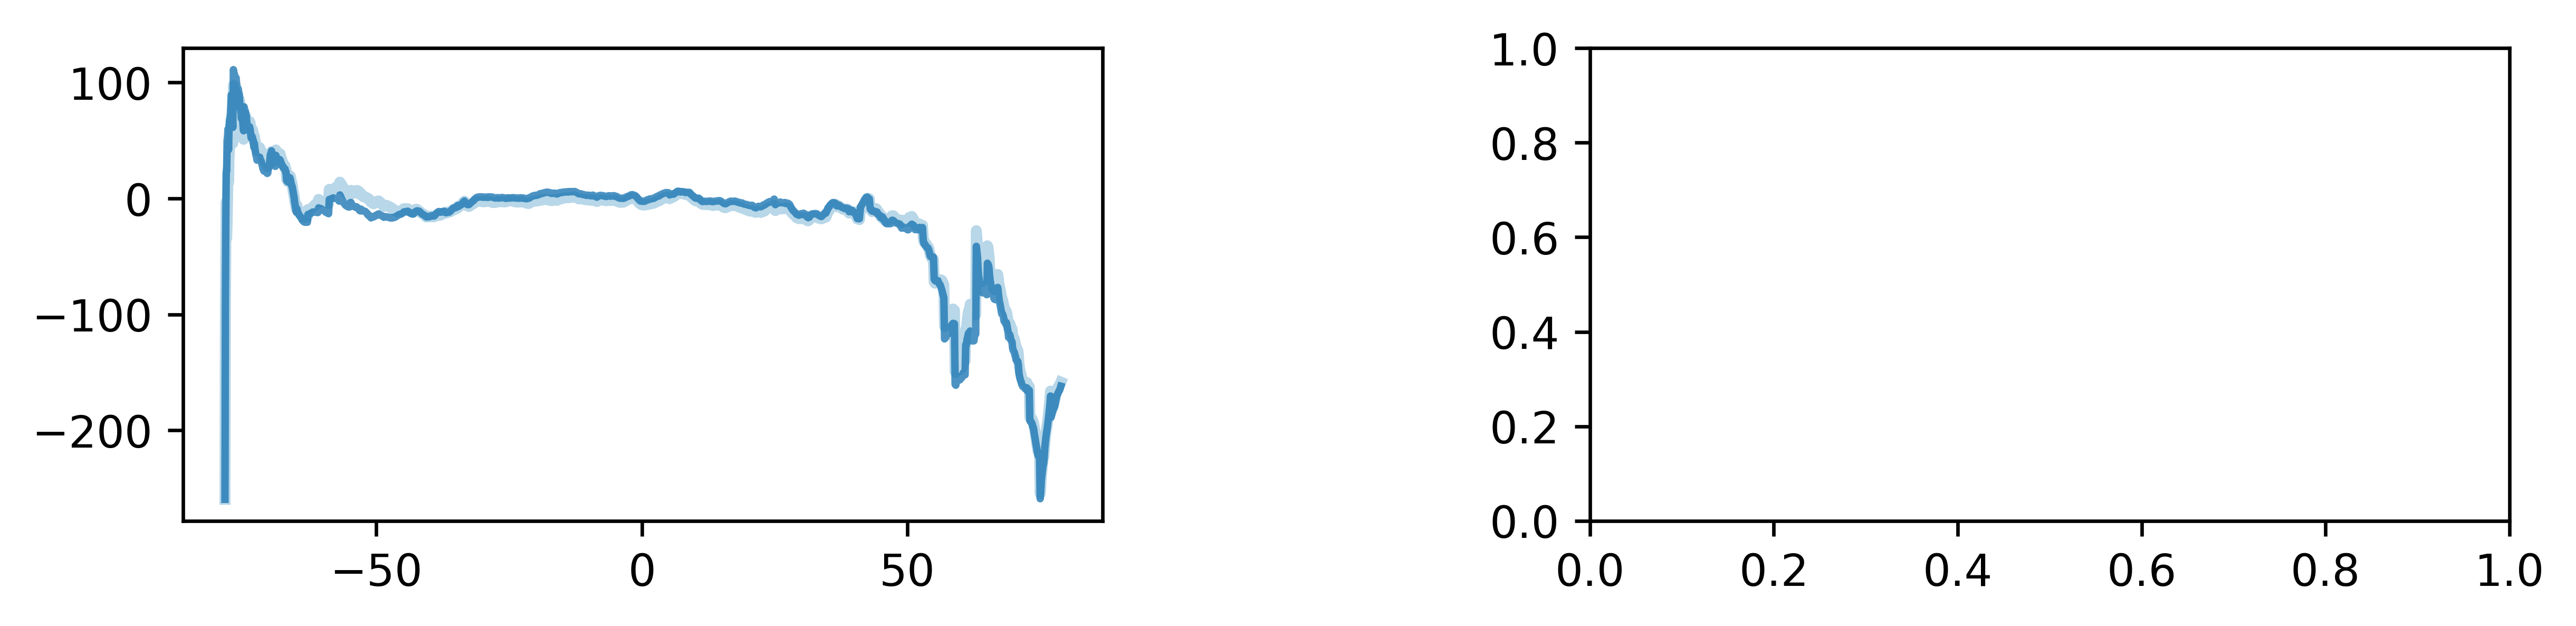

In [9]:
# create a figure
#fig = plt.figure()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), dpi=600)
fig.tight_layout(pad=8.0)


import matplotlib.pyplot as pl
colors = pl.cm.Paired(np.linspace(0,1,12))

plt.subplot(1,2,1)
plt.plot(GFDL_MLD_BFF11_winter_zm.yh.values,GFDL_MLD_BFF11_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[0],label='BFF11 GFDL',linewidth =2.5,alpha=0.8)
plt.plot(GFDL_MLD_BOD23_winter_zm.yh.values,GFDL_MLD_BOD23_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[1],label='BOD23 GFDL',linewidth =1.7,alpha=0.8)

plt.plot(BLOM_lat.values,BLOM_MLD_BFF11_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[2],label='BFF11 BLOM',linewidth =2.5,alpha=0.8)
plt.plot(BLOM_lat.values,BLOM_MLD_BOD23_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[3],label='BOD23 BLOM tuned',linewidth =1.7,alpha=0.8)

plt.plot(CESM_MLD_BFF11_winter_zm.yh.values,CESM_MLD_BFF11_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[4],label='BFF11 CESM',linewidth =2.5,alpha=0.8)
plt.plot(CESM_MLD_BOD23_winter_zm.yh.values,CESM_MLD_BOD23_winter_zm.values-MLD_winter_ARGO_interp_zonal_mean.values,color=colors[5],label='BOD23 CESM',linewidth =1.7,alpha=0.8)


#plt.xlim([-75,75])
plt.ylim([0,350])
plt.grid(linewidth=.1)
#plt.legend(fontsize=6,loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Latitude')
plt.ylabel('MLD difference from Argo (m)')
plt.title('Winter')


plt.subplot(1,2,2)
plt.plot(GFDL_MLD_BFF11_summer_zm.yh.values,GFDL_MLD_BFF11_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[0],label='BFF11 GFDL',linewidth =2.5,alpha=0.8)
plt.plot(GFDL_MLD_BOD23_summer_zm.yh.values,GFDL_MLD_BOD23_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[1],label='BOD23 GFDL',linewidth =1.7,alpha=0.8)

plt.plot(BLOM_lat.values,BLOM_MLD_BFF11_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[2],label='BFF11 BLOM',linewidth =2.5,alpha=0.8)
plt.plot(BLOM_lat.values,BLOM_MLD_BOD23_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[3],label='BOD23 BLOM',linewidth =1.7,alpha=0.8)

plt.plot(CESM_MLD_BFF11_summer_zm.yh.values,CESM_MLD_BFF11_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[4],label='BFF11 CESM',linewidth =2.5,alpha=0.8)
plt.plot(CESM_MLD_BOD23_summer_zm.yh.values,CESM_MLD_BOD23_summer_zm.values-MLD_summer_ARGO_interp_zonal_mean,color=colors[5],label='BOD23 CESM',linewidth =1.7,alpha=0.8)



#plt.xlim([-75,75])
plt.grid(linewidth=.1)
plt.legend(fontsize=6,loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Latitude')
plt.ylabel('MLD difference from Argo (m)')
plt.title('Summer')



# save figure
plt.savefig('./figures/MLD_zonal_mean_diff_obs')

